In [3]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

In [5]:
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target
class_names = train_data.target_names
print("Training Documents: ", len(X_train_text))
print("Testing Documents: ", len(X_test_text))
print("Number of Classes: ", len(class_names))
vectorizer = CountVectorizer(stop_words='english', min_df=2)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


Training Documents:  11314
Testing Documents:  7532
Number of Classes:  20


In [6]:
vectorizer = CountVectorizer(stop_words='english', min_df=2)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(f"Training feature matrix: {X_train.shape}")
print(f"Testing feature matrix: {X_test.shape}")
mnb = MultinomialNB()

mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [ ]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary=binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary=binary_vectorizer.transform(
    X_test_text
)

In [8]:
bnb = BernoulliNB()
bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb=bnb.predict(
    X_test_binary
)

In [9]:
acc_mnb = accuracy_score(y_test, y_pred_mnb)
prec_mnb = precision_score(y_test, y_pred_mnb, average='weighted')
rec_mnb = recall_score(y_test, y_pred_mnb, average='weighted')
f1_mnb = f1_score(y_test, y_pred_mnb, average='weighted')
acc_bnb = accuracy_score(y_test, y_pred_bnb)
prec_bnb = precision_score(y_test, y_pred_bnb, average='weighted')
rec_bnb = recall_score(y_test, y_pred_bnb, average='weighted')
f1_bnb = f1_score(y_test, y_pred_bnb, average='weighted')

In [20]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Multinomial NB": [acc_mnb, prec_mnb, rec_mnb, f1_mnb],
    "Bernoulli NB": [acc_bnb, prec_bnb, rec_bnb, f1_bnb]
})

print(results)

      Metric  Multinomial NB  Bernoulli NB
0   Accuracy        0.651089      0.485130
1  Precision        0.642532      0.627034
2     Recall        0.651089      0.485130
3   F1 Score        0.629644      0.480839


C:\Users\abhij\AppData\Local\Temp\ipykernel_24076\2697569224.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


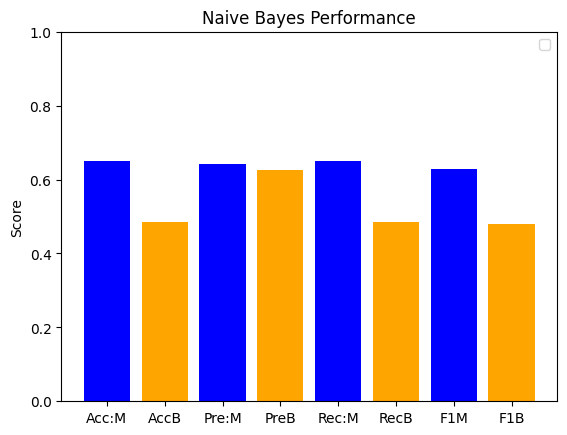

In [25]:
import matplotlib.pyplot as plt

labels = ["Acc:M","AccB", "Pre:M","PreB", "Rec:M","RecB", "F1M","F1B"]

scores = [acc_mnb,acc_bnb,prec_mnb,prec_bnb,rec_mnb,rec_bnb,f1_mnb,f1_bnb]

colors = ["blue", "orange", "blue", "orange","blue", "orange", "blue", "orange"]

plt.bar(labels, scores, color=colors)
plt.legend()
plt.title("Naive Bayes Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()